In [1]:
import numpy as np
from io import StringIO
import glob

# proliferating e-anyons, m-anyons subthreshold

def load_error_rate(filename):
    """Read one output_*.txt file and return its 'Error Rate:' block as a 16x8 array."""
    with open(filename) as f:
        text = f.read()
    # grab everything between the "Error Rate:" header and the next blank line
    block = text.split("Error Rate:")[1].split("\n\n")[0]
    return np.loadtxt(StringIO(block))

# list the output files to combine (one file == one run)
files = sorted(glob.glob(
    "/Users/aubreyzhang/Documents/ILP_DATA/logicalZs/conditionalZ/pz_2_heralded_Z/output_*.txt"))

# stack into the same shape as before: (n_files, 16, 8)
runs = np.stack([load_error_rate(f) for f in files])

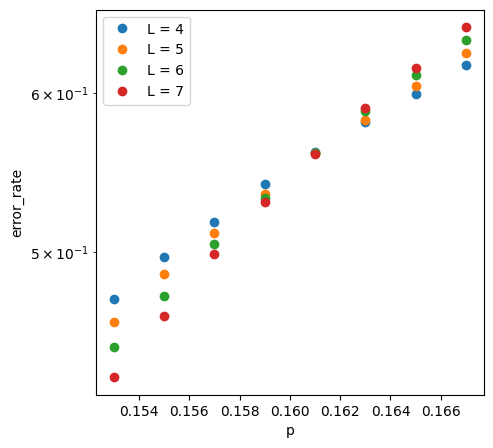

In [2]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.153, 0.155, 0.157, 0.159, 0.161, 0.163, 0.165, 0.167]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [3]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.153, 0.155, 0.157, 0.159, 0.161, 0.163, 0.165, 0.167]), 4)

L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 10000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [4]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.16097154  1.43168907  0.5593799   3.86158355 -6.44121311]
Parameter standard deviations: [5.16351517e-04 1.53304662e-01 6.40275721e-03 5.00511944e-01
 4.58825708e+00]


np.float64(4.59269754190084)

In [5]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.16096798   1.42571483   0.55936149   3.85041835  -6.57602915
 -20.22076998]
Parameter standard deviations: [5.18105574e-04 1.77928446e-01 6.40600440e-03 5.29907463e-01
 4.97393941e+00 3.02338899e+02]


np.float64(4.579473540639139)

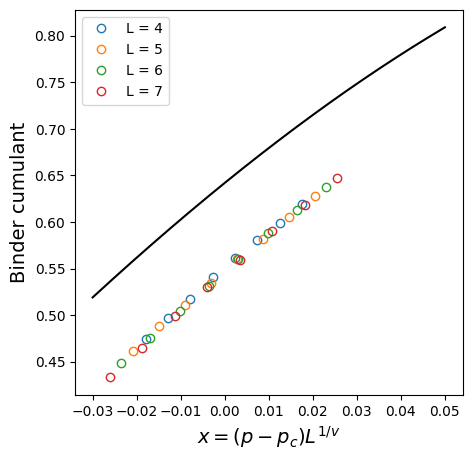

In [6]:
pc = 0.16107576
nu = 1.48950467
A = 0.6419381
B = 3.83773775
C = -9.16936443
D =  -14.9870922

p = [0.154, 0.156, 0.158, 0.16, 0.162, 0.164, 0.166, 0.168]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.03, 0.05, 1000)
y_data = A + B*x_data + C*(x_data**2) +D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()